In [6]:
import tensorflow as tf
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
pip install xlns

In [3]:
import xlns as xl

**Code Challenge 1:**

The following 2 code snippets show that xlns and numpy (np) are interoperable and an xlnsnp object can be converted to a numpy array and vice versa. np supports custom object arrays. However, although TensorFlow (TF) is interoperable with np, it is not *compatible* with xlns currently and throws errors as it doesn't support custom-object tensors

In [7]:

#Q1
a=xl.xlnsnp([5.0,2.0])
b=xl.xlnsnp([3.0,4.0])
c=xl.xlnsnp(np.array([[1,2,3]])) #works: xlnsnp can accept python lists and np arrays
print(a)
print(c)
a_np=np.array(a)            #xlnsnp object can be converted to np array
print(a_np)             #xlns and np are interoperable and a np array can be converted to xlnsnp object and vice-versa but not TF tensor
a_tf=tf.constant(a)
print(a_tf)

[xlns(5.00000016087236) xlns(1.9999999986889088)]
[[xlns(1.0) xlns(1.9999999986889088) xlns(2.9999999688096786)]]
[xlnsnp(5.00000016087236) xlnsnp(1.9999999986889088)]


ValueError: AttributeError: 'numpy.int64' object has no attribute '__len__'
Traceback (most recent call last):

  File "/usr/local/lib/python3.11/dist-packages/xlns.py", line 819, in __len__
    return self.nd.__len__()
           ^^^^^^^^^^^^^^^

AttributeError: 'numpy.int64' object has no attribute '__len__'



In [8]:
x = xl.xlnsnp([2.0, 3.0])
print("XLNS input:", x)
y=x.nd #returns a numpy array
y_tf=tf.convert_to_tensor(y)  #this works as TF is interoperable with np
print(y_tf)
x_tf = tf.convert_to_tensor(x) #fails to work as TF is not interoperable with xlns and doesn't support custom object tensors
print("TensorFlow tensor:", x_tf)

XLNS input: [xlns(1.9999999986889088) xlns(2.9999999688096786)]
tf.Tensor([16777216 26591258], shape=(2,), dtype=int64)


ValueError: AttributeError: 'numpy.int64' object has no attribute '__len__'
Traceback (most recent call last):

  File "/usr/local/lib/python3.11/dist-packages/xlns.py", line 819, in __len__
    return self.nd.__len__()
           ^^^^^^^^^^^^^^^

AttributeError: 'numpy.int64' object has no attribute '__len__'



**Code Challenge 2:**

The following code snippet implements the fully connected network using TF's sequential api as per the presented architecture. The leaky relu coefficient of 0.0078125 (default), 0.000 regularization (default), 0.5 split and validation split (default), batch_size =1 (default) were used from the arn_generic.py since their values were not passed through the terminal. The passed epoch number of 7 was used.
**SGD Optimizer** was used since it resembles simple gradient descent and backpropagation implemented in arn_generic.py as compared to ADAM

**Note:** The code challenge specifies the ReLU is used in the internal layer, however, an inspection into the source code shows a leakyReLU default coefficient. Hence, LeakyReLU is used here, although, ReLU-model can also be presented.
**Note:** The Sequential Model takes more time (as highlighted in the training log) than the arn_generic.py example file but shows better convergence. Although the example code runs much faster than the TF model, it overfits the dataset and shows weaker convergence.


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist
import numpy as np


(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape((-1, 28*28)).astype("float32") / 255.0
x_test = x_test.reshape((-1, 28*28)).astype("float32") / 255.0

# Hyperparameters from CLI, some passed rest default
learning_rate = 0.01
batch_size = 1
val_split = 0.5
weight_decay_lambda = 0.000  # No L2 regularization
leaking_coeff = 0.0078125    # For LeakyReLU


model = models.Sequential([
    layers.Dense(100,
                 kernel_regularizer=regularizers.l2(weight_decay_lambda), #possibility of regularizarion is added
                 input_shape=(784,)),
    layers.LeakyReLU(alpha=leaking_coeff), #we could have used ReLU(negative_slope=leaking_coeff)
    layers.Dense(10,
                 activation='softmax',
                 kernel_regularizer=regularizers.l2(weight_decay_lambda))
])


optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train model
h=model.fit(x_train, y_train,
          epochs=7,
          batch_size=batch_size,
          validation_split=val_split)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/7
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 153s 5ms/step - accuracy: 0.8668 - loss: 0.4463 - val_accuracy: 0.9298 - val_loss: 0.2350
Epoch 2/7
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 201s 5ms/step - accuracy: 0.9585 - loss: 0.1431 - val_accuracy: 0.9591 - val_loss: 0.1413
Epoch 3/7
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 210s 5ms/step - accuracy: 0.9747 - loss: 0.0869 - val_accuracy: 0.9624 - val_loss: 0.1295
Epoch 4/7
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 132s 4ms/step - accuracy: 0.9801 - loss: 0.0650 - val_accuracy: 0.9628 - val_loss: 0.1290
Epoch 5/7
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 143s 4ms/step - accuracy: 0.9832 - loss: 0.0523 - val_accuracy: 0.9636 - val_loss: 0.1333
Epoch 6/7
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 171s 5ms/step - accuracy: 0.9891 - loss: 0.0383 - val_accuracy: 0.9685 - val_loss: 0.1125
Epoch 7/7
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 191s 5ms/step - accuracy: 0.9931 - loss: 0.0265 - val_accuracy: 0.9640 - val_loss: 0.1291


In [9]:

test_loss, test_accuracy = model.evaluate(x_test, y_test, batch_size=1, verbose=1)
print(f"Test Loss: {test_loss: }")
print(f"Test Accuracy: {test_accuracy: }")


10000/10000 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9638 - loss: 0.1233

Test Loss:  0.10996806621551514
Test Accuracy:  0.9672999978065491


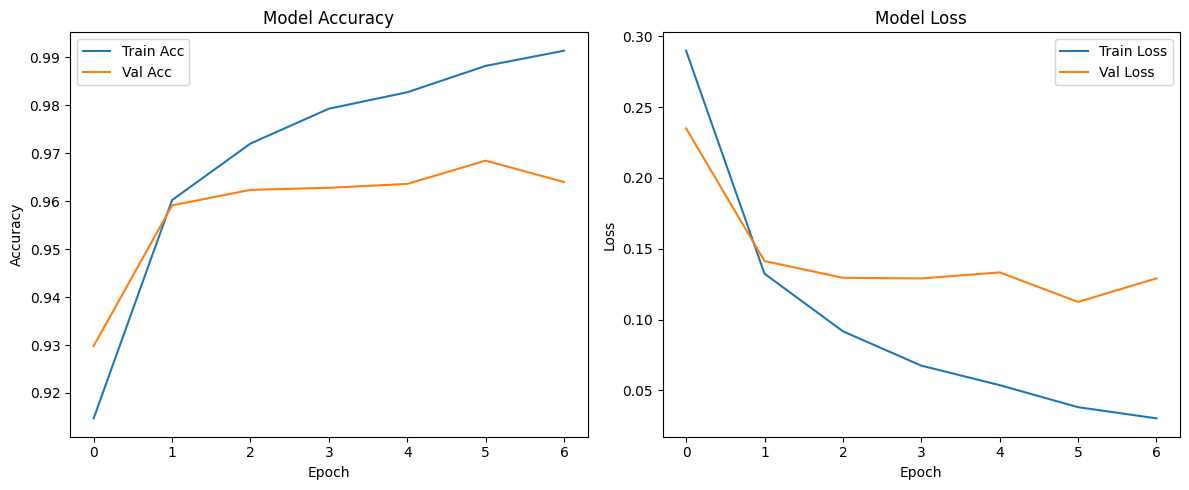

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(h.history['accuracy'], label='Train Acc')
plt.plot(h.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(h.history['loss'], label='Train Loss')
plt.plot(h.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
!git clone https://github.com/xlnsresearch/xlns.git


Cloning into 'xlns'...
remote: Enumerating objects: 575, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 575 (delta 61), reused 64 (delta 50), pack-reused 482 (from 2)
Receiving objects: 100% (575/575), 21.12 MiB | 33.42 MiB/s, done.
Resolving deltas: 100% (304/304), done.


In [15]:
%cd xlns/examples
!ls


/content/xlns/examples
arn_generic.py	 arnnpv.py	  inv_naive.py		 testlikecpp32.py      weightin.npz
arnnpb.py	 arnud.py	  mnist_demo.py		 testnpbufunc.py
arnnp_lpvip.py	 arnv.py	  mnist.npz		 testnpufunc.py
arnnpr_lpvip.py  basel.py	  testlikecpp16lpvip.py  testutahlikecpp32.py
arnnp_utah.py	 faithfultest.py  testlikecpp16.py	 testvufunc.py


In [16]:
!python3 arn_generic.py --type xlnsnp --num_epoch 7


arbitrary base np LNS. Also xl.hstack, xl. routines in softmax
testing new softmax and * instead of @ for delta
works with type xlnsnp
#= 50  xlns b= two   F= 10  B= 1.0006771306930664  batch= 1  lr= 0.01
using ./weightin.npz
At Epoch 1:
#= 50  xlns b= two   F= 10  B= 1.0006771306930664  batch= 1  lr= 0.01
train-set accuracy at epoch 1: 0.540000
Val-set accuracy at epoch 1: 0.220000
At Epoch 2:
#= 50  xlns b= two   F= 10  B= 1.0006771306930664  batch= 1  lr= 0.01
train-set accuracy at epoch 2: 0.700000
Val-set accuracy at epoch 2: 0.400000
At Epoch 3:
#= 50  xlns b= two   F= 10  B= 1.0006771306930664  batch= 1  lr= 0.01
train-set accuracy at epoch 3: 0.860000
Val-set accuracy at epoch 3: 0.520000
At Epoch 4:
#= 50  xlns b= two   F= 10  B= 1.0006771306930664  batch= 1  lr= 0.01
train-set accuracy at epoch 4: 0.900000
Val-set accuracy at epoch 4: 0.540000
At Epoch 5:
#= 50  xlns b= two   F= 10  B= 1.0006771306930664  batch= 1  lr= 0.01
train-set accuracy at epoch 5: 0.920000
Val-set accu

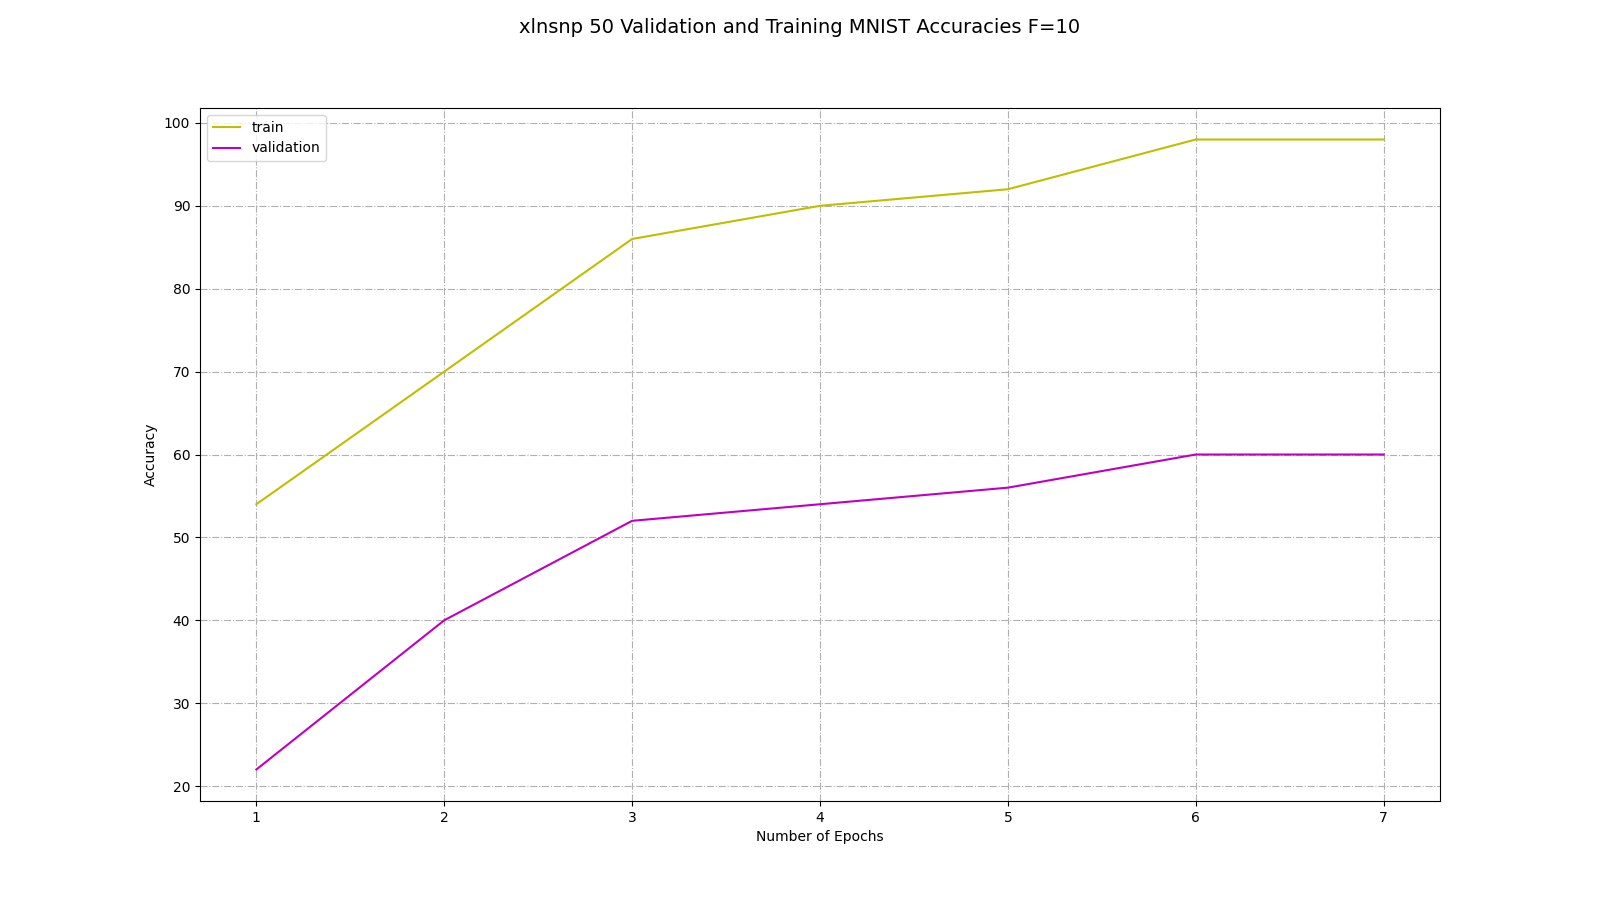

In [20]:
from IPython.display import Image, display
display(Image('genericaccuracy.png'))

In [21]:
!python3 arn_generic.py --type float --num_epoch 7


arbitrary base np LNS. Also xl.hstack, xl. routines in softmax
testing new softmax and * instead of @ for delta
works with type float
#= 50  xlns b= two   F= 10  B= 1.0006771306930664  batch= 1  lr= 0.01
using ./weightin.npz
At Epoch 1:
#= 50  xlns b= two   F= 10  B= 1.0006771306930664  batch= 1  lr= 0.01
train-set accuracy at epoch 1: 0.540000
Val-set accuracy at epoch 1: 0.220000
At Epoch 2:
#= 50  xlns b= two   F= 10  B= 1.0006771306930664  batch= 1  lr= 0.01
train-set accuracy at epoch 2: 0.700000
Val-set accuracy at epoch 2: 0.400000
At Epoch 3:
#= 50  xlns b= two   F= 10  B= 1.0006771306930664  batch= 1  lr= 0.01
train-set accuracy at epoch 3: 0.860000
Val-set accuracy at epoch 3: 0.520000
At Epoch 4:
#= 50  xlns b= two   F= 10  B= 1.0006771306930664  batch= 1  lr= 0.01
train-set accuracy at epoch 4: 0.900000
Val-set accuracy at epoch 4: 0.540000
At Epoch 5:
#= 50  xlns b= two   F= 10  B= 1.0006771306930664  batch= 1  lr= 0.01
train-set accuracy at epoch 5: 0.920000
Val-set accur

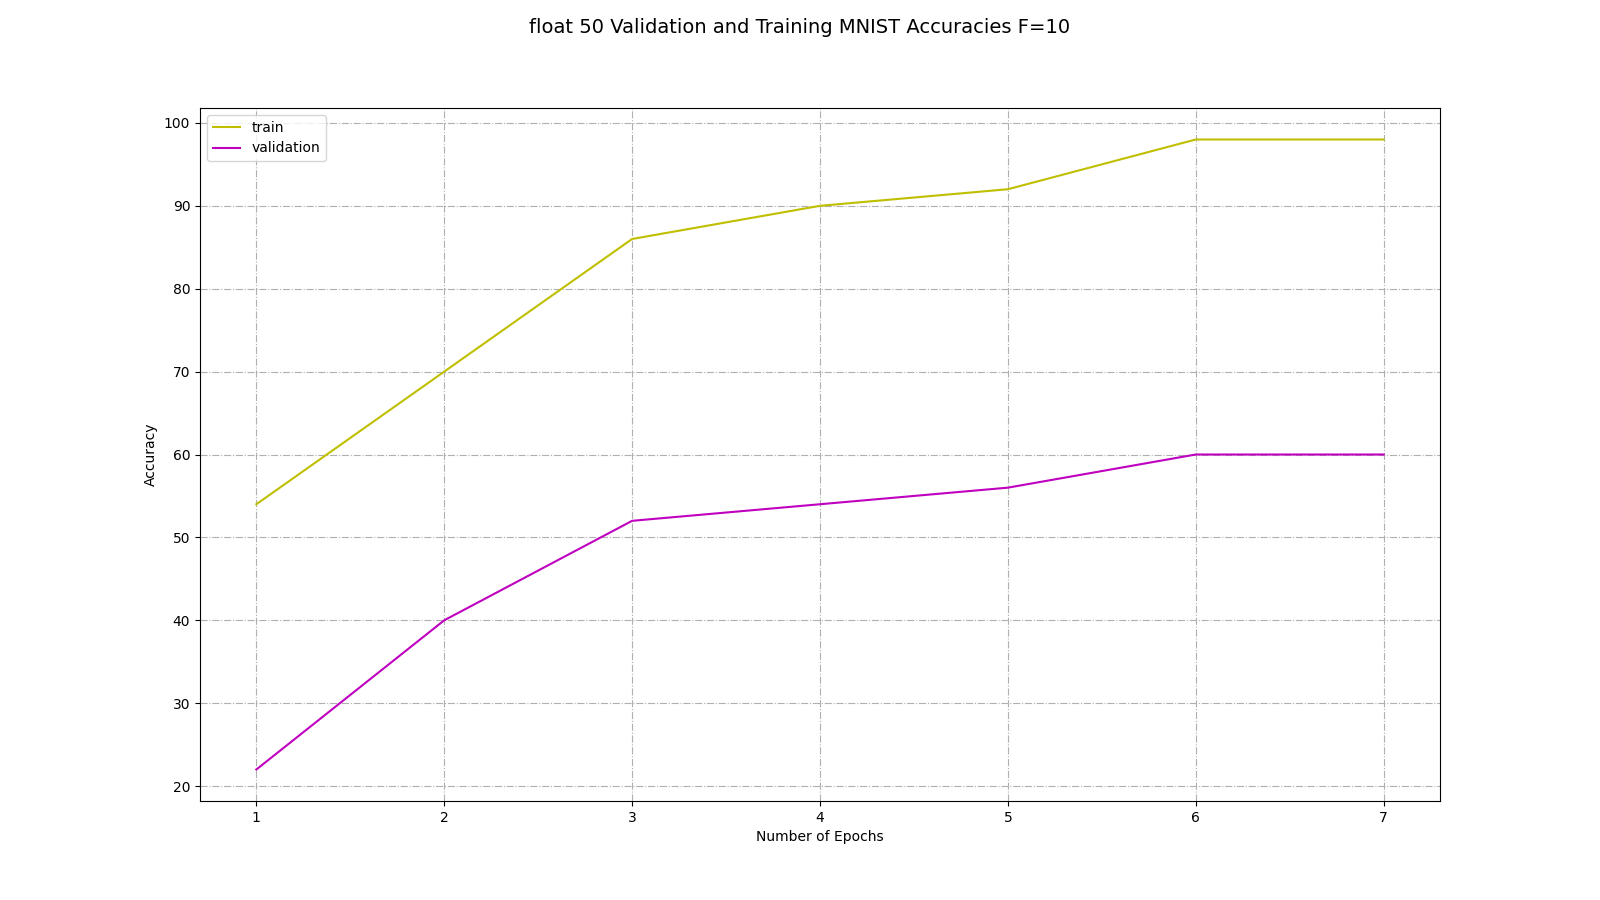

In [22]:
from IPython.display import Image, display
display(Image('genericaccuracy.png'))

**Code Challenge 3:**
Implementation of LNS Operations like addition in TensorFlow

In [23]:
import numpy as np
import tensorflow as tf
import xlns as xl


def lns_to_float(x_data):
    x = x_data // 2 #Getting the log magnitude
    s = x_data % 2 #the sign bit

    x_float = tf.pow(2.0, tf.cast(x, tf.float32) / (2**23))  #opposite shifting
    x_float = tf.where(tf.equal(s, 1), -x_float, x_float)

    return x_float





def sbdb_ufunc_ideal2(x, sign_bit):

    #print(((tf.math.log(1+tf.pow(2.0,tf.cast((x/2**23),tf.float32)))/tf.math.log(2.0)))*2**23) #very small so removed scaling
    #print("hello",tf.cast((((tf.math.log(tf.abs(1-2*tf.cast(sign_bit,tf.float32) +tf.pow(2.0,tf.cast((x/2**23),tf.float32))))/tf.math.log(2.0))))*2**23,tf.int64)*2)
    correction=tf.cast((((tf.math.log(tf.abs(1-2*tf.cast(sign_bit,tf.float32) +tf.pow(2.0,tf.cast((x/2**23),tf.float32))))/tf.math.log(2.0)))*2**23),tf.int64)*2 #+ tf.cast(sign_bit, tf.int64)#why adding sign_bit?? if sb==1 do substraction

    return correction

def lns_add_int64(x, y):
    max_part = tf.maximum(x, y)
    sign_bit_x=x%2
    sign_bit_y=y%2


    delta = -tf.abs((x // 2) - (y // 2)) #removed sign bit
    sign_bit = (x ^ y) & 1   # 0 same sign, 1 opposite sign

    sign=0
    sign = tf.where(
    tf.logical_and(tf.equal(sign_bit, 0), tf.equal(sign_bit_x, 1)),
    tf.constant(1, dtype=tf.int64),
    tf.where(
        tf.equal(sign_bit, 1),
        tf.where(tf.greater(tf.math.floordiv(x, 2), tf.math.floordiv(y, 2)), sign_bit_x, sign_bit_y),
        tf.constant(0, dtype=tf.int64)
    )
)
    #sign=tf.where(tf.logical_and(tf.equal(sign_bit,0),tf.equal(sign_bit_x,1)),1,tf.where(tf.equal(sign_bit,1),tf.where(x//2>y//2,sign_bit_x,sign_bit_y)))

    correction = sbdb_ufunc_ideal2(delta, sign_bit)
    fsum=max_part + correction*2


    return max_part + tf.cast(correction,tf.int64)

def lns_sub_int64(x, y):
    return lns_add_int64(x, y^1)

def lns_mul_int64(x, y):
    return x + y

def lns_div_int64(x, y):
    INT64_MIN = tf.constant(-9223372036854775808, dtype=tf.int64)  # Special zero representation in LNS
    INT64_MAX_positive = tf.constant(9223372036854775806, dtype=tf.int64) #will lead to float infinity
    INT64_MAX_negative = tf.constant(9223372036854775807, dtype=tf.int64)
    INT64_NAN = tf.constant(9223372036854775805, dtype=tf.int64)  # A placeholder for NaN


    is_nan = tf.logical_and(tf.equal(x, INT64_MIN), tf.equal(y, INT64_MIN))


    is_inf = tf.logical_and(tf.not_equal(x, INT64_MIN), tf.equal(y, INT64_MIN))


    normal_div = (x - y + (y & 1)) ^ (y & 1)
    inf_result = tf.where(x&1==1 , INT64_MAX_negative, INT64_MAX_positive)


    t_nd = tf.where(is_nan, INT64_NAN, #if else
            tf.where(is_inf, inf_result,
                     tf.where(tf.equal(x, INT64_MIN), INT64_MIN,
            normal_div)))  #otherwise


    return t_nd

def lns_div_int64_np(self, v): #just present for benchmarking normal xlnsnp division by 0 cases

    if isinstance(v, int) or isinstance(v, float):
        return self / xl.xlnsnp(v)

    if isinstance(v, xl.xlnsnp):

        t = xl.xlnsnp("")

        INT64_MIN = np.int64(-9223372036854775808)
        INT64_MAX_POS = np.int64(9223372036854775806)  # Positive infinity
        INT64_MAX_NEG = np.int64(9223372036854775807)  # Negative infinity
        INT64_NAN = np.int64(9223372036854775805)  # NaN for 0/0

        is_nan = np.logical_and(self.nd == INT64_MIN, v.nd == INT64_MIN)

        is_inf = np.logical_and(self.nd != INT64_MIN, v.nd == INT64_MIN)

        normal_div = (self.nd - v.nd + (v.nd&1)) ^ (v.nd&1)


        inf_result = np.where(self.nd & 1 == 1, INT64_MAX_NEG, INT64_MAX_POS)#signbit


        t.nd = np.where(is_nan, INT64_NAN,
                np.where(is_inf, inf_result,
                np.where(self.nd == INT64_MIN, INT64_MIN, normal_div)))


        return t

    else:

        return self / xl.xlnsnp(v)




    #return x - y
def lns_matmul2_int64(A, B):
    result = []
    for i in range(tf.shape(A)[0]):  # Rows of A
        row_result = []
        for j in range(tf.shape(B)[1]):  # Columns of B
            sum_log = None
            for k in range(tf.shape(A)[1]):  # Inner dimension
                product_log = lns_mul_int64(A[i, k], B[k, j])  # Log-space multiplication
                sum_log = product_log if sum_log is None else lns_add_int64(sum_log, product_log)
            row_result.append(sum_log)
        result.append(row_result)
    return tf.convert_to_tensor(result, dtype=tf.int64)



x = xl.xlnsnp([2,1]) #x is made using numpy internally using class
y = xl.xlnsnp([0,5.0])
print("input:",x)
print(y)

x_nd = tf.convert_to_tensor(x.nd, dtype=tf.int64)
y_nd = tf.convert_to_tensor(y.nd, dtype=tf.int64)


add=lns_add_int64(x_nd, y_nd)
sub=lns_sub_int64(x_nd, y_nd)
mul=lns_mul_int64(x_nd, y_nd)
div=lns_div_int64(x_nd, y_nd)
div_xl=lns_div_int64_np(x, y)
print("DIVXL",div_xl)
 #not showing infinity as in integer it is infinity not in float and we can only get to so much internally using int
print("LNS Addition (tf):", lns_to_float(add).numpy())
print("LNS Subtraction(tf) :", lns_to_float(sub).numpy())
print("LNS Multiplication (tf):", lns_to_float(mul).numpy())
print("LNS Division (tf):", lns_to_float(div).numpy())
print()
print("LNS Addition (xlns):", x+y)
print("LNS Subtraction(xlns) :", x-y)
print("LNS Multiplication (xlns)):", x*y)
print("LNS Division (xlns)(module):", x/y)
print("LNS Division (xlns) updated (np)", div_xl)
#Final float values after operations are correct, final log int64 (add, sub,etc.) values are also correct

#print("LNS Addition:", add.numpy())
#print("LNS Subtraction:", sub.numpy())
#print("LNS Multiplication:", mul.numpy())
#print("LNS Division:", div.numpy())






input: [xlns(1.9999999986889088) xlns(1.0)]
[xlns(0) xlns(5.00000016087236)]
DIVXL [xlns(2.7397669538084295E165492990114) xlns(0.1999999935651058)]
LNS Addition (tf): [2.        6.0000005]
LNS Subtraction(tf) : [ 2. -4.]
LNS Multiplication (tf): [0. 5.]
LNS Division (tf): [inf 0.2]

LNS Addition (xlns): [xlns(1.9999999986889088) xlns(5.999999933686084)]
LNS Subtraction(xlns) : [xlns(1.9999999986889088) xlns(-4.00000032527398)]
LNS Multiplication (xlns)): [xlns(0) xlns(5.00000016087236)]
LNS Division (xlns)(module): [xlns(7.299813549266042E-165492990115) xlns(0.1999999935651058)]
LNS Division (xlns) updated (np) [xlns(2.7397669538084295E165492990114) xlns(0.1999999935651058)]


The above output shows that for addition, subtraction, and multiplication, the implemented TF functions and xlns overloaded operators work roughly same. However, as highlighted in my PR, I have implemented a division function with division by 0 handled, so although it differs with xlns in division by 0, but it gives the same result for division by non zero cases. The accuracy of this approach was validated on 10 Million numbers.

In [24]:
a=xl.xlnsnp(np.array([[1],[2],[3]])) #can't pass nested list directly to xlnsnp (PR raised)
b=xl.xlnsnp(np.array([[1,2,3]]))
a=tf.convert_to_tensor(a.nd, dtype=tf.int64)
b=tf.convert_to_tensor(b.nd,dtype=tf.int64)
print(tf.shape(b)[1])
ans=lns_matmul2_int64(a,b)             #Implementation of custom Matmul in TF using LNS arithmetic
print(lns_to_float(ans))

tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor(
[[1.        2.        3.       ]
 [2.        4.        5.9999995]
 [3.        5.9999995 9.       ]], shape=(3, 3), dtype=float32)
